In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect and load everything correctly
conn = sqlite3.connect('../Processed Data/processed_pharma_sfe.db')

# Load all 5 tables from the "Gold Standard" DB
sales = pd.read_sql("SELECT * FROM sales", conn)
reps = pd.read_sql("SELECT * FROM reps", conn)
territories = pd.read_sql("SELECT * FROM territories", conn)
calls = pd.read_sql("SELECT * FROM calls_cleaned", conn)
prescribers = pd.read_sql("SELECT * FROM prescribers_cleaned", conn)

conn.close()
print("All tables loaded successfully!")

All tables loaded successfully!


In [3]:
# 1. Calculate average achievement per territory
territory_achievement = sales.groupby('territory_id')['target_achievement_pct'].mean().reset_index()

# 2. Merge data to get potential and achievement for each rep
rep_analysis = reps.merge(territories[['territory_id', 'market_potential_index']], on='territory_id')
rep_analysis = rep_analysis.merge(territory_achievement, on='territory_id')

# 3. Define the quadrants using medians
pot_median = rep_analysis['market_potential_index'].median()
ach_median = rep_analysis['target_achievement_pct'].median()

def segment_rep(row):
    if row['target_achievement_pct'] >= ach_median:
        return 'Star' if row['market_potential_index'] >= pot_median else 'Cash Cow (Coasting)'
    else:
        return 'Question Mark (Mismatch)' if row['market_potential_index'] >= pot_median else 'Dog (Laggard)'

rep_analysis['performance_segment'] = rep_analysis.apply(segment_rep, axis=1)

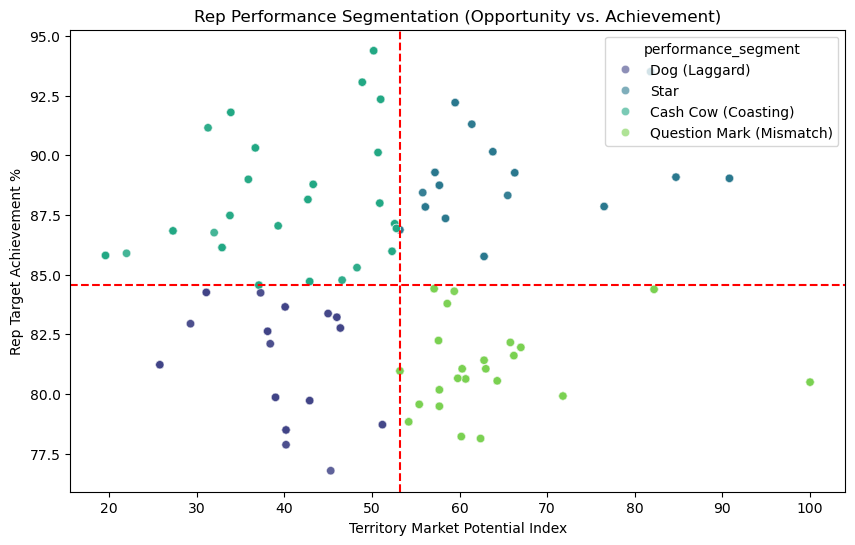

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rep_analysis, x='market_potential_index', y='target_achievement_pct', 
                hue='performance_segment', palette='viridis', alpha=0.6)

# Add the red crosshairs at the medians
plt.axhline(ach_median, color='red', linestyle='--')
plt.axvline(pot_median, color='red', linestyle='--')

plt.title('Rep Performance Segmentation (Opportunity vs. Achievement)')
plt.xlabel('Territory Market Potential Index')
plt.ylabel('Rep Target Achievement %')
plt.show()

In [5]:
# 1. Calculate the counts for each performance segment
summary_table = rep_analysis['performance_segment'].value_counts().reset_index()
summary_table.columns = ['Performance Segment', 'Rep Count']

# 2. Calculate the percentage of the total workforce for each segment
summary_table['Percentage (%)'] = (summary_table['Rep Count'] / len(rep_analysis) * 100).round(2)

# 3. Sort by percentage to highlight the biggest groups
summary_table = summary_table.sort_values(by='Percentage (%)', ascending=False)

# 4. Display the final deliverable
print("Deliverable: Rep Force Segment Summary Table")
display(summary_table)

# 5. Extract the "Question Mark" Headline for your future report
qm_pct = summary_table[summary_table['Performance Segment'] == 'Question Mark (Mismatch)']['Percentage (%)'].iloc[0]
print(f"\nHEADLINE FINDING: {qm_pct}% of the field force are currently 'Question Marks' (High Potential, Low Achievement).")

Deliverable: Rep Force Segment Summary Table


,Performance Segment,Rep Count,Percentage (%)
0,Question Mark (Mismatch),161,32.2
1,Cash Cow (Coasting),152,30.4
2,Star,103,20.6
3,Dog (Laggard),84,16.8



HEADLINE FINDING: 32.2% of the field force are currently 'Question Marks' (High Potential, Low Achievement).
